In [2]:
# Define problem
# Always two features
# Ideal weight of first feature is always 0.5, ideal weight of second feature is configurable
# Whether features are independent is configurable, when colinear, they are the same target feature with different amounts of noise
# Noise for the first feature is always 0.1, noise for the second feature is configurable
# Note that all of the three lines are like a small version of the feature sifting setup I'm already using with how features are generated with noise coefficients and such


# First experiment:
# Independent features, ideal weight of second feature with ideal weights of 0.1, 0.3, 0.5, 0.7, and 0.9
# The second feature should also have noise of 0.1
# Both features are trained with LMS with a step-size of 0.01 for 100k steps
# I want to plot several plots, vertically stacked, each for a different ideal weight of the second feature
# Each plot should include lines for:
#   - The current weights of both features
#   - A dashed line for the ideal weight of the second feature
#   - Traces of changes to the weights with varying decay rates (0.9, 0.99, 0.999)
#   - h value from IDBD (compute even though learning happens with a constant step-size)
#   - h value from IDBD3 (compute even though learning happens with a constant step-size)


# The goal of this experiment is to figure out which, if any, of the metrics I've mentioned would be sufficient to determine when a feature should be protected
# The indicators I'm considering are traces of changes to the weights, traces to changes to the step-size (when using idbd),
#   and the h value of IDBD or IDBD3 (when its sign flips) (which can be computed even when not using IDBD).


In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def make_problem_data(
    n_steps,
    target_weights,          # teacher weight on each feature's CLEAN signal (scalar or list)
    *,
    feature_noise=0.0,       # noise coefficient c per feature (scalar or list)
    target_noise_std=0.1,    # std of additive Gaussian noise on the target
    shared_signal=False,     # if True, all features are noisy views of ONE signal
    seed=0,
):
    """Generate (features, target) for the feature-sifting linear-regression probe.

    The target is a fixed "teacher network": ``y = sum_j target_weights[j] * s_j
    + noise``, built from the CLEAN signals ``s_j``. The learner instead sees the
    noisy features ``f_j = (1 - c_j) * s_j + c_j * U(-1, 1)``. The teacher weights
    are held fixed regardless of the feature noise; the learner's *optimal* weight
    on a noisy feature is attenuated away from the teacher weight (regression
    dilution -- see ``optimal_weight``), so the dashed reference in the plots is
    the computed optimum, not the teacher weight.

    Every knob that may vary across experiments is a parameter:

    - ``target_weights``: teacher weight per feature on its clean signal -> sets
      the number of features. With clean features (``c = 0``) this is also the
      learner's optimal weight.
    - ``feature_noise``: per-feature noise coefficient ``c`` in
      ``f = (1 - c) * s + c * U(-1, 1)``;  ``c = 0`` gives a clean feature.
    - ``target_noise_std``: std of the Gaussian noise added to the target.
    - ``shared_signal``: if True every feature is a noisy view of the *same*
      underlying signal (the colinear / "blocking" case); otherwise each feature
      has its own independent signal.

    Returns ``features`` (n_steps, n_feat) and ``y`` (n_steps,).
    """
    rng = np.random.default_rng(seed)
    target_weights = np.atleast_1d(np.asarray(target_weights, dtype=float))
    n_feat = len(target_weights)
    c = np.broadcast_to(np.asarray(feature_noise, dtype=float), (n_feat,))

    # underlying clean signals
    if shared_signal:
        s = rng.uniform(-1.0, 1.0, size=n_steps)
        signals = [s] * n_feat
    else:
        signals = [rng.uniform(-1.0, 1.0, size=n_steps) for _ in range(n_feat)]

    features = np.empty((n_steps, n_feat))
    y = rng.normal(0.0, target_noise_std, size=n_steps)
    for j in range(n_feat):
        feat_noise = rng.uniform(-1.0, 1.0, size=n_steps)
        features[:, j] = (1 - c[j]) * signals[j] + c[j] * feat_noise
        y = y + target_weights[j] * signals[j]   # teacher weight on the clean signal

    return features, y


def optimal_weight(target_weight, feature_noise):
    """Least-squares optimal weight on a single *independent* noisy feature.

    With ``f = (1 - c) * s + c * u`` (Var(s) == Var(u)) and target component
    ``target_weight * s``, the optimum is
        ``w* = Cov(f, y) / Var(f) = target_weight * (1 - c) / ((1 - c)**2 + c**2)``.
    The learner shrinks the weight (regression attenuation) as the feature gets
    noisier:  ``w* -> target_weight`` at ``c = 0`` and ``w* -> 0`` as ``c -> 1``.
    Assumes the feature's signal is independent of the other features' signals.
    """
    c = np.asarray(feature_noise, dtype=float)
    return target_weight * (1 - c) / ((1 - c) ** 2 + c ** 2)


In [ ]:
# ---------------------------------------------------------------------------
# First experiment: a single feature with clean inputs (no feature noise) and a
# noisy target, learned from a zero weight with constant-step-size LMS, while we
# *observe* candidate "maturity" indicators for its weight.
#
# Learning is plain LMS; the IDBD / IDBD3 h-traces are computed alongside with
# the same constant step-size, exactly as the project optimisers do:
#   IDBD : h <- h * max(1 - step_size*f**2, 0) + step_size * loss_grad
#   IDBD3: h <- h * max(1 - step_size*f**2, 0) +             loss_grad
# with loss_grad = 2*error*f. They never feed back into the weights.
# (With a constant step-size the two share the same decay term and differ only by
#  the factor step_size, so h_idbd == step_size * h_idbd3 exactly -- they coincide
#  once normalized.)
# ---------------------------------------------------------------------------

STEP_SIZE = 0.01
N_STEPS = 10_000
IDEAL_WEIGHTS = [0.0, 0.001, 0.01, 0.1, 0.5, 1.0]
TRACE_DECAYS = [0.9, 0.99, 0.999]


def run_lms_with_indicators(features, y, step_size=STEP_SIZE, trace_decays=TRACE_DECAYS,
                            w_init=None):
    """LMS over `features` (n_steps, n_feat); indicators are tracked for the
    feature under study, taken to be the LAST column. `step_size` is the constant
    LMS / IDBD step-size and the number of steps is set by len(features), so both
    are configurable per run. `w_init` defaults to zeros (a fresh weight); pass a
    vector to start e.g. an established weight at its optimum in the later blocking
    experiments."""
    n_steps, n_feat = features.shape
    tracked = n_feat - 1
    decays = np.asarray(trace_decays, dtype=float)
    n_dec = len(decays)

    w = np.zeros(n_feat) if w_init is None else np.asarray(w_init, dtype=float)
    h_idbd = 0.0
    h_idbd3 = 0.0
    dw_tr = np.zeros(n_dec)

    w_hist = np.empty((n_steps, n_feat))
    dw_trace_hist = np.empty((n_steps, n_dec))
    h_idbd_hist = np.empty(n_steps)
    h_idbd3_hist = np.empty(n_steps)

    for t in range(n_steps):
        f = features[t]
        error = float(w @ f) - y[t]              # y_hat - y  (project convention)

        fi = f[tracked]
        loss_grad = 2.0 * error * fi             # d(error**2)/dw_tracked
        decay_term = fi * fi                     # prediction-grad squared

        # IDBD / IDBD3 h-traces (observed only, constant step-size)
        keep = max(0.0, 1.0 - step_size * decay_term)
        h_idbd = h_idbd * keep + step_size * loss_grad
        h_idbd3 = h_idbd3 * keep + loss_grad

        # LMS weight update (constant step-size) for every weight
        dw = -step_size * (2.0 * error * f)
        w = w + dw

        # EMA traces of the tracked weight's changes
        dw_tr = decays * dw_tr + (1.0 - decays) * dw[tracked]

        w_hist[t] = w
        dw_trace_hist[t] = dw_tr
        h_idbd_hist[t] = h_idbd
        h_idbd3_hist[t] = h_idbd3

    return {'w': w_hist, 'dw_trace': dw_trace_hist,
            'h_idbd': h_idbd_hist, 'h_idbd3': h_idbd3_hist}


results = {}
for w_ideal in IDEAL_WEIGHTS:
    # single clean feature (no feature noise), target noise = 0.1
    feats, targ = make_problem_data(N_STEPS, [w_ideal], feature_noise=0.0,
                                    target_noise_std=0.1, seed=0)
    results[w_ideal] = run_lms_with_indicators(feats, targ, step_size=STEP_SIZE)


In [79]:
def _norm_peak(a):
    m = np.max(np.abs(a))
    return a / m if m > 0 else a

W_COLOR = 'black'
DW_COLORS = ['#3953e2', '#9923DC', '#029999']  # Brighter indigo, purple, dark aqua
H_IDBD3_COLOR = '#35b729'

### Reading the plots

One panel per ideal weight $w^*$ (including $w^* = 0$ — a useless feature whose weight
should stay at zero). A single feature with clean inputs is learned from a zero weight;
all the noise lives in the target ($\sigma = 0.1$).

**Left axis (true scale, black):** the weight (solid) and its ideal value (dashed). The
grey vertical line marks where the weight first reaches 90% of its ideal — a rough
"matured" reference (omitted for $w^* = 0$).

**Right axis (linear, coloured):** the candidate maturity indicators, each normalized to
unit peak so they are comparable (raw magnitudes differ by orders of magnitude). All are
shown in the weight-change sign convention ($-h$), so each indicator is positive while
the weight grows and collapses toward (and flips around) zero once the weight matures.

The IDBD / IDBD3 $h$-traces use the project's exact recursion
$h_t = h_{t-1}\,\max(1 - \alpha f^2,\,0) + (\alpha\ \text{or}\ 1)\cdot\text{loss\_grad}$,
with $\alpha$ held constant. They share the *same* decay multiplier and their additive
terms differ only by the constant factor $\alpha$, so $h^{\text{IDBD}}_t = \alpha\,
h^{\text{IDBD3}}_t$ for all $t$ — i.e. they are exactly proportional and coincide after
normalization. They only diverge once $\alpha$ is allowed to adapt (then the decay
multipliers differ too), which is a later experiment.


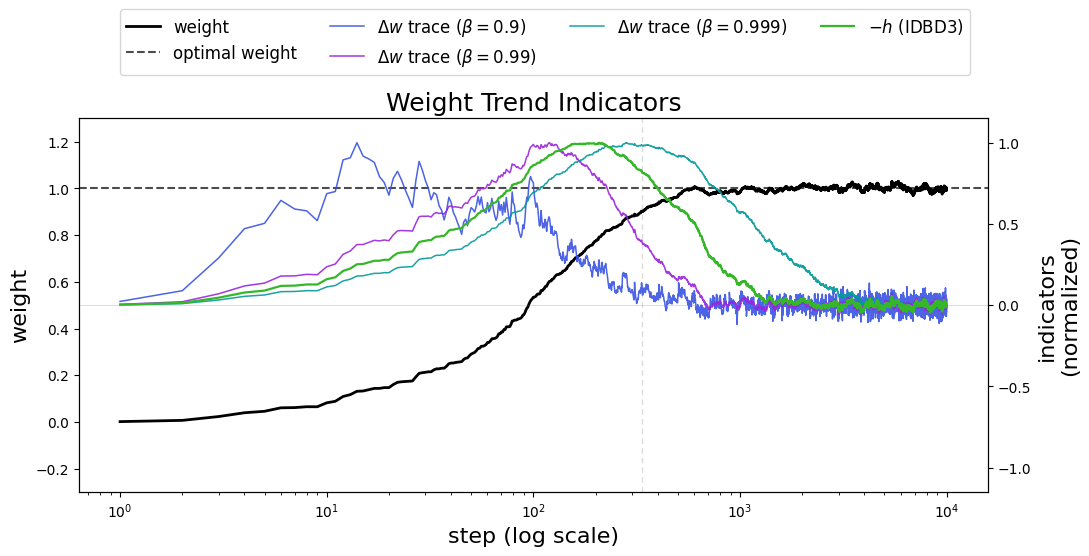

In [89]:

# Only plot the first optimal weight (single plot)
plot_steps = np.arange(1, N_STEPS + 1)

w_ideal = IDEAL_WEIGHTS[-1]
res = results[w_ideal]
w_opt = optimal_weight(w_ideal, 0.0)   # clean features -> equals the teacher weight

fig, ax = plt.subplots(figsize=(11, 5))
# --- left axis: the weight (true scale, black) ---
ax.plot(plot_steps, res['w'][:, -1], color=W_COLOR, lw=2.0, label='weight')
ax.axhline(w_opt, color=W_COLOR, ls='--', lw=1.5, alpha=0.7, label='optimal weight')
ax.set_xscale('log')
ax.set_ylabel('weight', fontsize=16)
ax.set_ylim(-w_opt * 0.3, w_opt * 1.3)
ax.set_title(f'Weight Trend Indicators', fontsize=18)

# rough "matured" reference: weight first reaches 90% of its optimum (skip if 0)
if w_opt > 0:
    hit = np.where(res['w'][:, -1] >= 0.9 * w_opt)[0]
    if len(hit):
        ax.axvline(hit[0] + 1, color='0.55', ls=(0, (4, 3)), lw=1.0, alpha=0.3)

# --- right axis: normalized maturity indicators (one colour each) ---
ax2 = ax.twinx()
for k, d in enumerate(TRACE_DECAYS):
    ax2.plot(plot_steps, _norm_peak(res['dw_trace'][:, k]),
             color=DW_COLORS[k], lw=1.1, alpha=0.9, label=f'$\Delta w$ trace ($\\beta = {d}$)')
ax2.plot(plot_steps, _norm_peak(-res['h_idbd3']), color=H_IDBD3_COLOR, lw=1.6,
         label='$-h$ (IDBD3)')
ax2.axhline(0.0, color='0.5', lw=0.6, alpha=0.3)
ax2.set_ylim(-1.15, 1.15)
ax2.set_ylabel('indicators\n(normalized)', fontsize=16)

ax.set_xlabel('step (log scale)', fontsize=16)

# Build legend with left and right handles/labels
hL, lL = ax.get_legend_handles_labels()
hR, lR = ax2.get_legend_handles_labels()
# Place the legend just above the axes, closer to the plot to reduce empty space
legend = fig.legend(
    hL + hR, lL + lR, loc='upper center', ncol=4,
    fontsize=12, bbox_to_anchor=(0.5, 1.12),
)
fig.tight_layout(rect=(0, 0, 1, 0.97))  # adjust so legend fits closely above plot
plt.show()


/tmp/ipykernel_22776/3955052857.py:25: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim(-w_opt * 0.3, w_opt * 1.3)


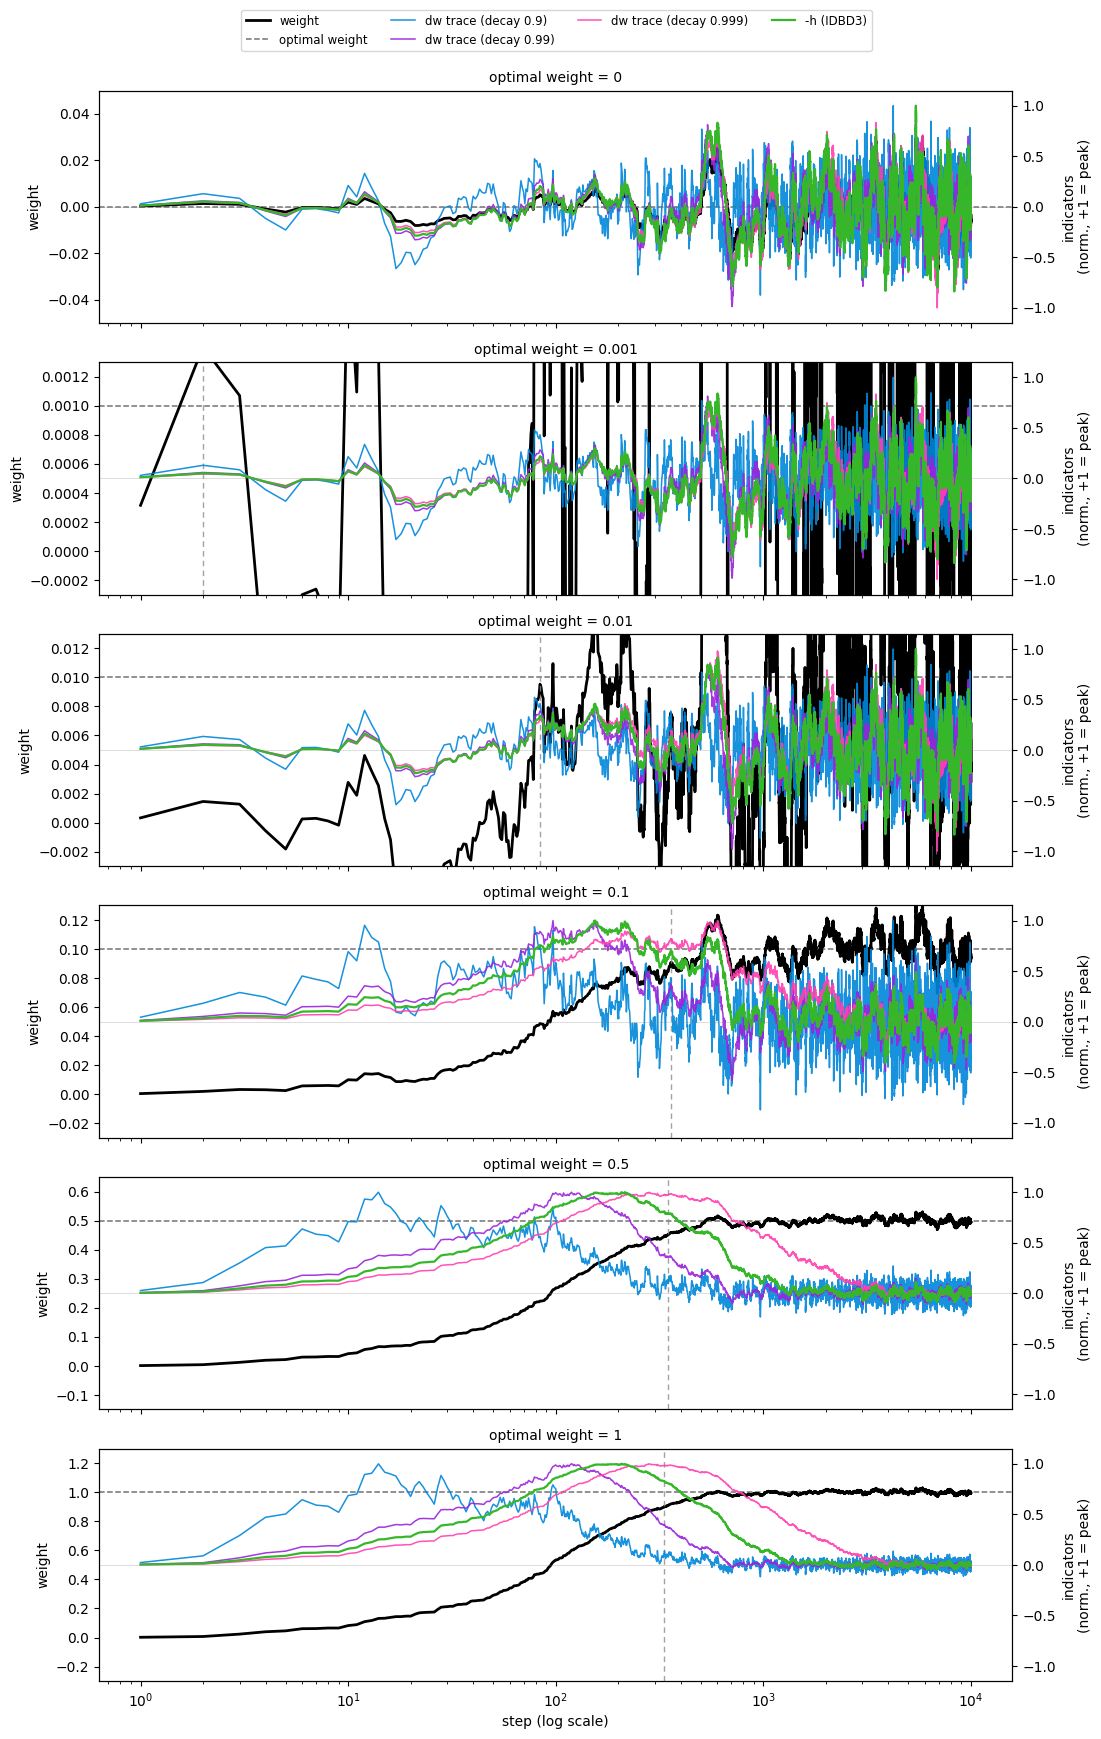

In [75]:
def _norm_peak(a):
    m = np.max(np.abs(a))
    return a / m if m > 0 else a


plot_steps = np.arange(1, N_STEPS + 1)

W_COLOR = 'black'
DW_COLORS = ['#0086DA', '#9923DC', '#FF40B0']
H_IDBD3_COLOR = '#35b729'

fig, axes = plt.subplots(len(IDEAL_WEIGHTS), 1,
                         figsize=(11, 2.9 * len(IDEAL_WEIGHTS)), sharex=True)
ax2_first = None
for ax, w_ideal in zip(axes, IDEAL_WEIGHTS):
    res = results[w_ideal]
    w_opt = optimal_weight(w_ideal, 0.0)   # clean features -> equals the teacher weight

    # --- left axis: the weight (true scale, black) ---
    ax.plot(plot_steps, res['w'][:, -1], color=W_COLOR, lw=2.0, label='weight')
    ax.axhline(w_opt, color=W_COLOR, ls='--', lw=1.1, alpha=0.55,
               label='optimal weight')
    ax.set_xscale('log')
    ax.set_ylabel('weight')
    ax.set_ylim(-w_opt * 0.3, w_opt * 1.3)
    ax.set_title(f'optimal weight = {w_opt:.3g}', fontsize=10)

    # rough "matured" reference: weight first reaches 90% of its optimum (skip if 0)
    if w_opt > 0:
        hit = np.where(res['w'][:, -1] >= 0.9 * w_opt)[0]
        if len(hit):
            ax.axvline(hit[0] + 1, color='0.55', ls=(0, (4, 3)), lw=1.0, alpha=0.8)

    # --- right axis: normalized maturity indicators (one colour each) ---
    ax2 = ax.twinx()
    for k, d in enumerate(TRACE_DECAYS):
        ax2.plot(plot_steps, _norm_peak(res['dw_trace'][:, k]),
                 color=DW_COLORS[k], lw=1.1, alpha=0.9, label=f'dw trace (decay {d})')
    ax2.plot(plot_steps, _norm_peak(-res['h_idbd3']), color=H_IDBD3_COLOR, lw=1.6,
             label='-h (IDBD3)')
    ax2.axhline(0.0, color='0.5', lw=0.6, alpha=0.3)
    ax2.set_ylim(-1.15, 1.15)
    ax2.set_ylabel('indicators\n(norm., +1 = peak)')
    if ax2_first is None:
        ax2_first = ax2

axes[-1].set_xlabel('step (log scale)')
hL, lL = axes[0].get_legend_handles_labels()
hR, lR = ax2_first.get_legend_handles_labels()
fig.legend(hL + hR, lL + lR, loc='upper center', ncol=4, fontsize=8.5,
           bbox_to_anchor=(0.5, 1.0))
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()


In [7]:
# Second experiment: feature noise.
# A single feature whose target-network (teacher) weight is held fixed at 1.0 while we
# sweep the feature's noise coefficient c over {0, 0.1, 0.5, 0.9, 0.95, 0.99, 0.999}.
# The teacher weight does not change with noise; what changes is the learner's OPTIMAL
# weight on the noisy feature, which is attenuated toward 0 as the feature becomes mostly
# noise (regression dilution). That computed optimum is the dashed reference in each plot.
#
# Same question as the first experiment -- which indicator best signals that the weight
# has matured -- now asked across feature-noise levels.


In [8]:
# ---------------------------------------------------------------------------
# Second experiment: hold the teacher weight at 1.0, sweep the feature noise.
# The teacher weight is fixed; the learner's *optimal* weight on the noisy
# feature attenuates with noise (computed by `optimal_weight`, shown dashed).
#
# Longer run (100k steps) at a smaller step-size (0.001) than the first
# experiment: the smaller step gives a lower steady-state misadjustment noise so
# the maturity indicators stay readable even when the optimum is tiny, and the
# longer horizon gives that smaller step time to converge.
# ---------------------------------------------------------------------------

EXP2_STEP_SIZE = 0.001
EXP2_N_STEPS = 100_000
TARGET_WEIGHT = 1.0
FEATURE_NOISES = [0.0, 0.1, 0.5, 0.9, 0.95, 0.99, 0.999]

noise_results = {}
for c in FEATURE_NOISES:
    feats, targ = make_problem_data(EXP2_N_STEPS, [TARGET_WEIGHT], feature_noise=c,
                                    target_noise_std=0.1, seed=0)
    noise_results[c] = run_lms_with_indicators(feats, targ, step_size=EXP2_STEP_SIZE)


### Reading the plots — feature noise

Same probe as the first experiment, but over a longer run (100k steps) at a smaller
step-size (0.001), with the single feature's **teacher weight held fixed at 1.0** while
we sweep its noise coefficient
$c \in \{0, 0.1, 0.5, 0.9, 0.95, 0.99, 0.999\}$ — one panel per $c$, noisier going down.

The teacher weight does not change, but the learner's **optimal** weight on the noisy
feature is *attenuated* (regression dilution):
$$w^*(c) = \frac{1 - c}{(1 - c)^2 + c^2},$$
which falls from $1.0$ at $c = 0$ toward $0$ as the feature becomes mostly noise. The
dashed horizontal line in each panel (and the value in its title) is this computed
optimum — not the teacher weight. Because the target amplitude stays bounded — and the
smaller step-size lowers the per-step misadjustment noise — the weight settles cleanly
at each $w^*(c)$ instead of being swamped by gradient noise.

Axes are exactly as in the first experiment: left = weight on its true scale (black),
right = the candidate maturity indicators, each normalized to unit peak and shown in the
$-h$ sign convention. The grey **vertical** dashed line marks the rough "matured" step —
the first step the weight reaches 90% of its optimum.


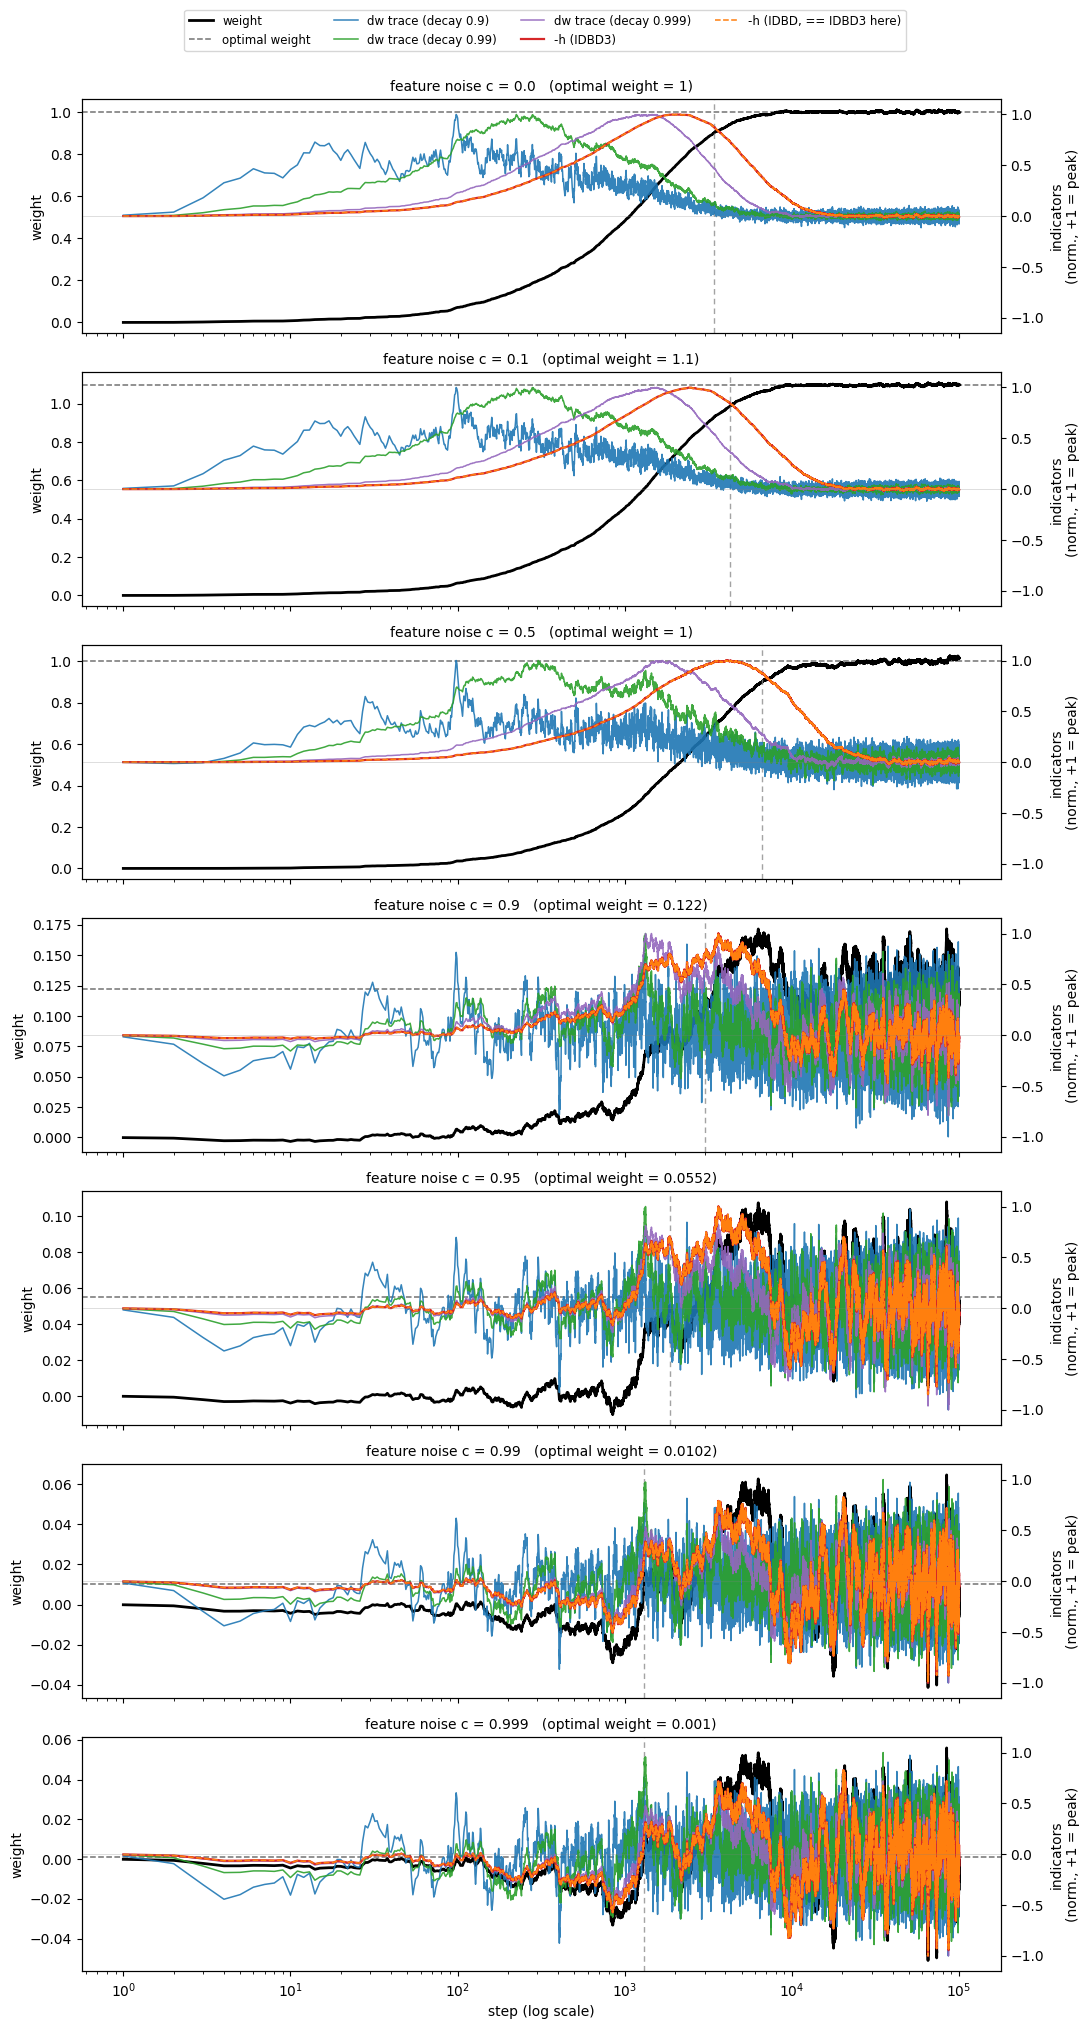

In [9]:
plot_steps = np.arange(1, EXP2_N_STEPS + 1)   # this experiment's own length

fig, axes = plt.subplots(len(FEATURE_NOISES), 1,
                         figsize=(11, 2.9 * len(FEATURE_NOISES)), sharex=True)
ax2_first = None
for ax, c in zip(axes, FEATURE_NOISES):
    res = noise_results[c]
    w_opt = optimal_weight(TARGET_WEIGHT, c)   # attenuated optimum for this noise level

    # --- left axis: the weight (true scale, black) ---
    ax.plot(plot_steps, res['w'][:, -1], color=W_COLOR, lw=2.0, label='weight')
    ax.axhline(w_opt, color=W_COLOR, ls='--', lw=1.1, alpha=0.55,
               label='optimal weight')
    ax.set_xscale('log')
    ax.set_ylabel('weight')
    ax.set_title(f'feature noise c = {c}   (optimal weight = {w_opt:.3g})', fontsize=10)

    # rough "matured" reference: weight first reaches 90% of its optimum
    if w_opt > 0:
        hit = np.where(res['w'][:, -1] >= 0.9 * w_opt)[0]
        if len(hit):
            ax.axvline(hit[0] + 1, color='0.55', ls=(0, (4, 3)), lw=1.0, alpha=0.8)

    # --- right axis: normalized maturity indicators (one colour each) ---
    ax2 = ax.twinx()
    for k, d in enumerate(TRACE_DECAYS):
        ax2.plot(plot_steps, _norm_peak(res['dw_trace'][:, k]),
                 color=DW_COLORS[k], lw=1.1, alpha=0.9, label=f'dw trace (decay {d})')
    ax2.plot(plot_steps, _norm_peak(-res['h_idbd3']), color=H_IDBD3_COLOR, lw=1.6,
             label='-h (IDBD3)')
    ax2.plot(plot_steps, _norm_peak(-res['h_idbd']), color=H_IDBD_COLOR, lw=1.1,
             ls='--', label='-h (IDBD, == IDBD3 here)')
    ax2.axhline(0.0, color='0.5', lw=0.6, alpha=0.3)
    ax2.set_ylim(-1.15, 1.15)
    ax2.set_ylabel('indicators\n(norm., +1 = peak)')
    if ax2_first is None:
        ax2_first = ax2

axes[-1].set_xlabel('step (log scale)')
hL, lL = axes[0].get_legend_handles_labels()
hR, lR = ax2_first.get_legend_handles_labels()
fig.legend(hL + hR, lL + lR, loc='upper center', ncol=4, fontsize=8.5,
           bbox_to_anchor=(0.5, 1.0))
fig.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()


In [10]:
# Later experiments will look at:
#   - Learning while optimizing the step-size
#   - Learning with different amounts of noise in the incumbent feature
#   - Learning with the estavblished feature blocking the incumbent feature

# These don't need to be implemented for now

In [11]:
# Maybe show above with step-size of 0.01, then show with different step-sizes to show the noisier ones can be done with smaller step-sizes,
# and show how it makes h smoother
# Then move to IDBD3 and show across each of the noise values again starting with a very small step-size

In [12]:
# ---------------------------------------------------------------------------
# Experiment 3: the feature-noise sweep again, but now sweeping the LMS
# step-size. Same single feature (teacher weight 1.0) at each noise level,
# learned with constant-step LMS at several step-sizes. Two things to see:
#   (1) a noisy feature that looks hopeless at a large step-size (0.01) learns
#       cleanly at a smaller one -- the steady-state misadjustment shrinks with
#       the step-size, so the weight settles at its (attenuated) optimum instead
#       of rattling around it. So the "noisier features want smaller step-sizes".
#   (2) the smaller the step-size, the SMOOTHER the IDBD3 h-trace. With a
#       constant step-size h is a geometric trace with decay (1 - alpha*f**2), so
#       a smaller alpha lengthens its averaging window: the sign-flip that marks
#       maturity becomes a clean zero-crossing instead of a jagged one (at the
#       cost of arriving later). I.e. picking a step-size small enough for the
#       feature's noise is exactly what makes h usable as a maturity signal.
#
# Reuses `run_lms_with_indicators` (passive IDBD/IDBD3 h, constant step) from the
# first experiment; the same (features, target) are shared across step-sizes so
# only the step-size differs within a noise level.
# ---------------------------------------------------------------------------

EXP3_N_STEPS = 400_000
EXP3_STEP_SIZES = [0.01, 0.001, 0.0001, 0.00001]          # large -> small
EXP3_FEATURE_NOISES = FEATURE_NOISES             # same sweep as experiment 2

step_results = {}
for c in EXP3_FEATURE_NOISES:
    feats, targ = make_problem_data(EXP3_N_STEPS, [TARGET_WEIGHT], feature_noise=c,
                                    target_noise_std=0.1, seed=0)
    step_results[c] = {
        ss: run_lms_with_indicators(feats, targ, step_size=ss)
        for ss in EXP3_STEP_SIZES
    }


### Effect of step-size

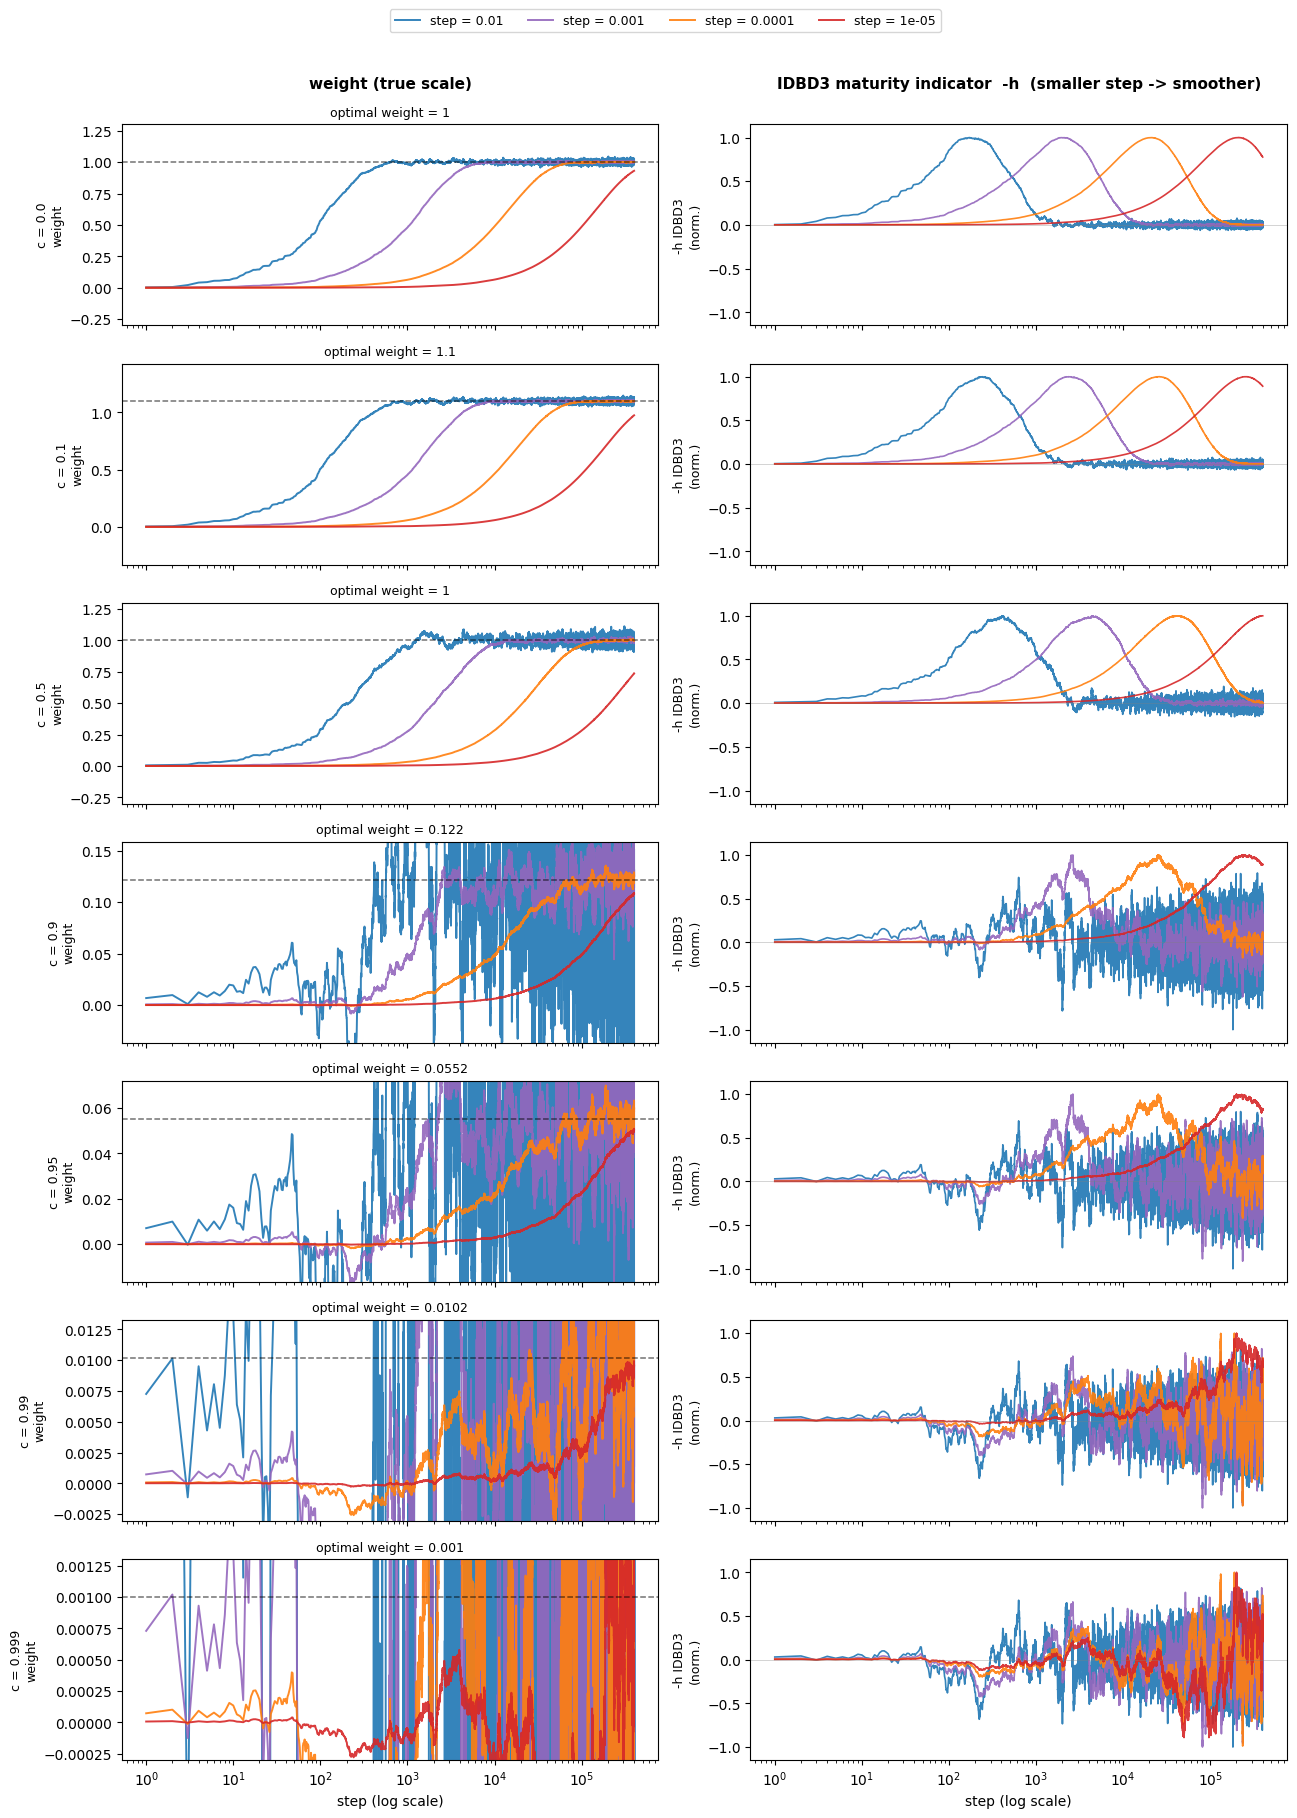

In [16]:
plot_steps = np.arange(1, EXP3_N_STEPS + 1)
SS_COLORS = ['tab:blue', 'tab:purple', 'tab:orange', 'tab:red']   # one per EXP3_STEP_SIZES (large -> small)

fig, axes = plt.subplots(len(EXP3_FEATURE_NOISES), 2,
                         figsize=(13, 2.6 * len(EXP3_FEATURE_NOISES)), sharex=True)
for row, c in enumerate(EXP3_FEATURE_NOISES):
    axL, axR = axes[row]
    w_opt = optimal_weight(TARGET_WEIGHT, c)

    for ss, col in zip(EXP3_STEP_SIZES, SS_COLORS):
        res = step_results[c][ss]
        # left: the weight on its true scale, one line per step-size
        axL.plot(plot_steps, res['w'][:, -1], color=col, lw=1.4, alpha=0.9,
                 label=f'step = {ss:g}')
        # right: the IDBD3 maturity indicator (-h), normalized to unit peak per run
        axR.plot(plot_steps, _norm_peak(-res['h_idbd3']), color=col, lw=1.2,
                 alpha=0.9, label=f'step = {ss:g}')

    axL.axhline(w_opt, color='black', ls='--', lw=1.1, alpha=0.55)
    axR.axhline(0.0, color='0.5', lw=0.6, alpha=0.4)
    axL.set_xscale('log'); axR.set_xscale('log')
    axR.set_ylim(-1.15, 1.15)
    axL.set_ylim(0 - w_opt * 0.3, w_opt * 1.3)
    axL.set_ylabel(f'c = {c}\nweight', fontsize=9)
    axR.set_ylabel('-h IDBD3\n(norm.)', fontsize=9)
    axL.set_title(f'optimal weight = {w_opt:.3g}', fontsize=9)

axes[0][0].annotate('weight (true scale)', xy=(0.5, 1.18), xycoords='axes fraction',
                    ha='center', fontsize=11, fontweight='bold')
axes[0][1].annotate('IDBD3 maturity indicator  -h  (smaller step -> smoother)',
                    xy=(0.5, 1.18), xycoords='axes fraction', ha='center',
                    fontsize=11, fontweight='bold')
axes[-1][0].set_xlabel('step (log scale)')
axes[-1][1].set_xlabel('step (log scale)')

hL, lL = axes[0][0].get_legend_handles_labels()
fig.legend(hL, lL, loc='upper center', ncol=len(EXP3_STEP_SIZES), fontsize=9,
           bbox_to_anchor=(0.5, 1.0))
fig.tight_layout(rect=(0, 0, 1, 0.965))
plt.show()


### Reading the plots — step-size sweep

The feature-noise sweep from experiment 2, now run at three constant step-sizes
($0.01$ red, $0.001$ orange, $0.0001$ blue). One **row per noise level** $c$ (noisier
going down); **left** = the weight on its true scale (dashed black = the attenuated
optimum $w^*(c)$), **right** = the IDBD3 maturity indicator $-h$, each normalized to
unit peak so the *shape* is comparable across step-sizes.

Two effects, both pointing the same way:

- **Noisier features want smaller step-sizes (left).** At $c = 0.01$ the large step is
  fine — it converges almost instantly. As $c$ grows the large-step weight increasingly
  *rattles* around $w^*$ (steady-state misadjustment $\propto \alpha$); dropping the
  step-size lets the weight actually **settle** at the (tiny) optimum instead of being
  swamped by gradient noise.
- **Smaller step-sizes smooth $h$ (right).** With a constant step the trace decays by
  $(1 - \alpha f^2)$ each step, so a smaller $\alpha$ is a longer averaging window: the
  $-h$ curve goes from a jagged, hard-to-threshold mess at $0.01$ to a clean hump that
  rises while the weight grows and crosses zero once it matures — at the price of that
  crossing arriving later.

Takeaway: $h$ is only a usable "this feature has matured" signal if the step-size is
small enough for the feature's noise level. That motivates **letting the step-size
adapt per feature**, which is experiment 4.


In [14]:
# ---------------------------------------------------------------------------
# Experiment 4: actually LEARN with IDBD3 (adaptive per-feature step-size),
# starting from a very small step-size, across the same feature-noise sweep.
#
# Experiments 1-3 only OBSERVED h while LMS learned at a fixed step. IDBD3 closes
# the loop and meta-learns the step-size beta = log(alpha). Following the
# project's optax_idbd3 (linear / 'prediction_grads' version), with the
# prediction gradient g_pred = d(y_hat)/dw = x (the input) and the loss gradient
# g_loss = d(error**2)/dw = 2*error*x:
#     beta  <- beta + meta_lr * g_pred * h          (meta-update, uses OLD h)
#     alpha  = exp(beta)
#     w     <- w - alpha * g_loss                    (weight update)
#     h     <- h * max(1 - alpha*x**2, 0) + g_loss   (IDBD3 trace, decay term x**2)
# Two things to note about the recursion: the meta-update is driven by the
# PREDICTION gradient x (NOT the loss gradient), and because the model is linear
# the h-decay term is simply x**2 -- the curvature / Fisher term d(g_loss)/dw for
# LMS. (The h additive term is g_loss with no alpha factor; that "no alpha" is
# what distinguishes IDBD3 from plain IDBD.)
#
# Starting alpha tiny (1e-4) is the point of the experiment: from a safe small
# value IDBD3 ramps alpha UP while the feature is being fit, then holds it at a
# level set by the feature's noise -- noisier features settle at a smaller alpha,
# recovering on its own the hand-tuned "smaller step for noisier features" of
# experiment 3. meta_lr is kept modest (3e-4): bare IDBD3 has no autostep
# effective-step normalisation, so an aggressive meta rate lets the unnormalised
# step-size run away at low noise; a small init + modest meta rate ramps cleanly
# and stays stable (and converges to w*(c)) at every noise level.
# ---------------------------------------------------------------------------

EXP4_N_STEPS = 100_000
EXP4_INIT_LR = 1e-4          # the "very small" starting step-size
EXP4_META_LR = 3e-4          # modest: keeps the unnormalised step-size stable
EXP4_FEATURE_NOISES = FEATURE_NOISES


def run_idbd3(features, y, *, init_lr, meta_lr, trace_decays=TRACE_DECAYS,
              w_init=None):
    """IDBD3 (project optax_idbd3, linear 'prediction_grads' version) over
    `features` (n_steps, n_feat): the step-size is meta-learned per feature from a
    log(init_lr) start, driven by the PREDICTION gradient with the h-decay term
    x**2. Indicators are tracked for the feature under study (the LAST column).
    Returns the weight, the adapted step-size `alpha`, the IDBD3 h-trace, and the
    same dw EMA traces as the LMS runner so the maturity indicators line up across
    experiments."""
    n_steps, n_feat = features.shape
    tracked = n_feat - 1
    decays = np.asarray(trace_decays, dtype=float)
    n_dec = len(decays)

    w = np.zeros(n_feat) if w_init is None else np.asarray(w_init, dtype=float)
    beta = np.full(n_feat, np.log(init_lr))
    h = np.zeros(n_feat)
    dw_tr = np.zeros(n_dec)

    w_hist = np.empty((n_steps, n_feat))
    alpha_hist = np.empty((n_steps, n_feat))
    dw_trace_hist = np.empty((n_steps, n_dec))
    h_idbd3_hist = np.empty(n_steps)

    for t in range(n_steps):
        f = features[t]
        error = float(w @ f) - y[t]               # y_hat - y (project convention)
        loss_grad = 2.0 * error * f               # d(error**2)/dw
        pred_grad = f                             # d(y_hat)/dw  (linear model -> x)
        decay_term = f * f                        # x**2  (curvature term for LMS)

        # meta-update of the per-feature step-size: PREDICTION grad * OLD h
        beta = beta + meta_lr * pred_grad * h
        alpha = np.exp(beta)

        # weight update with the adapted step-size
        dw = -alpha * loss_grad
        w = w + dw

        # IDBD3 h-trace (decay term x**2; additive term loss_grad, no alpha)
        keep = np.maximum(0.0, 1.0 - alpha * decay_term)
        h = h * keep + loss_grad

        # EMA traces of the tracked weight's changes
        dw_tr = decays * dw_tr + (1.0 - decays) * dw[tracked]

        w_hist[t] = w
        alpha_hist[t] = alpha
        dw_trace_hist[t] = dw_tr
        h_idbd3_hist[t] = h[tracked]

    return {'w': w_hist, 'alpha': alpha_hist, 'dw_trace': dw_trace_hist,
            'h_idbd3': h_idbd3_hist}


idbd3_results = {}
for c in EXP4_FEATURE_NOISES:
    feats, targ = make_problem_data(EXP4_N_STEPS, [TARGET_WEIGHT], feature_noise=c,
                                    target_noise_std=0.1, seed=0)
    idbd3_results[c] = run_idbd3(feats, targ, init_lr=EXP4_INIT_LR,
                                 meta_lr=EXP4_META_LR)


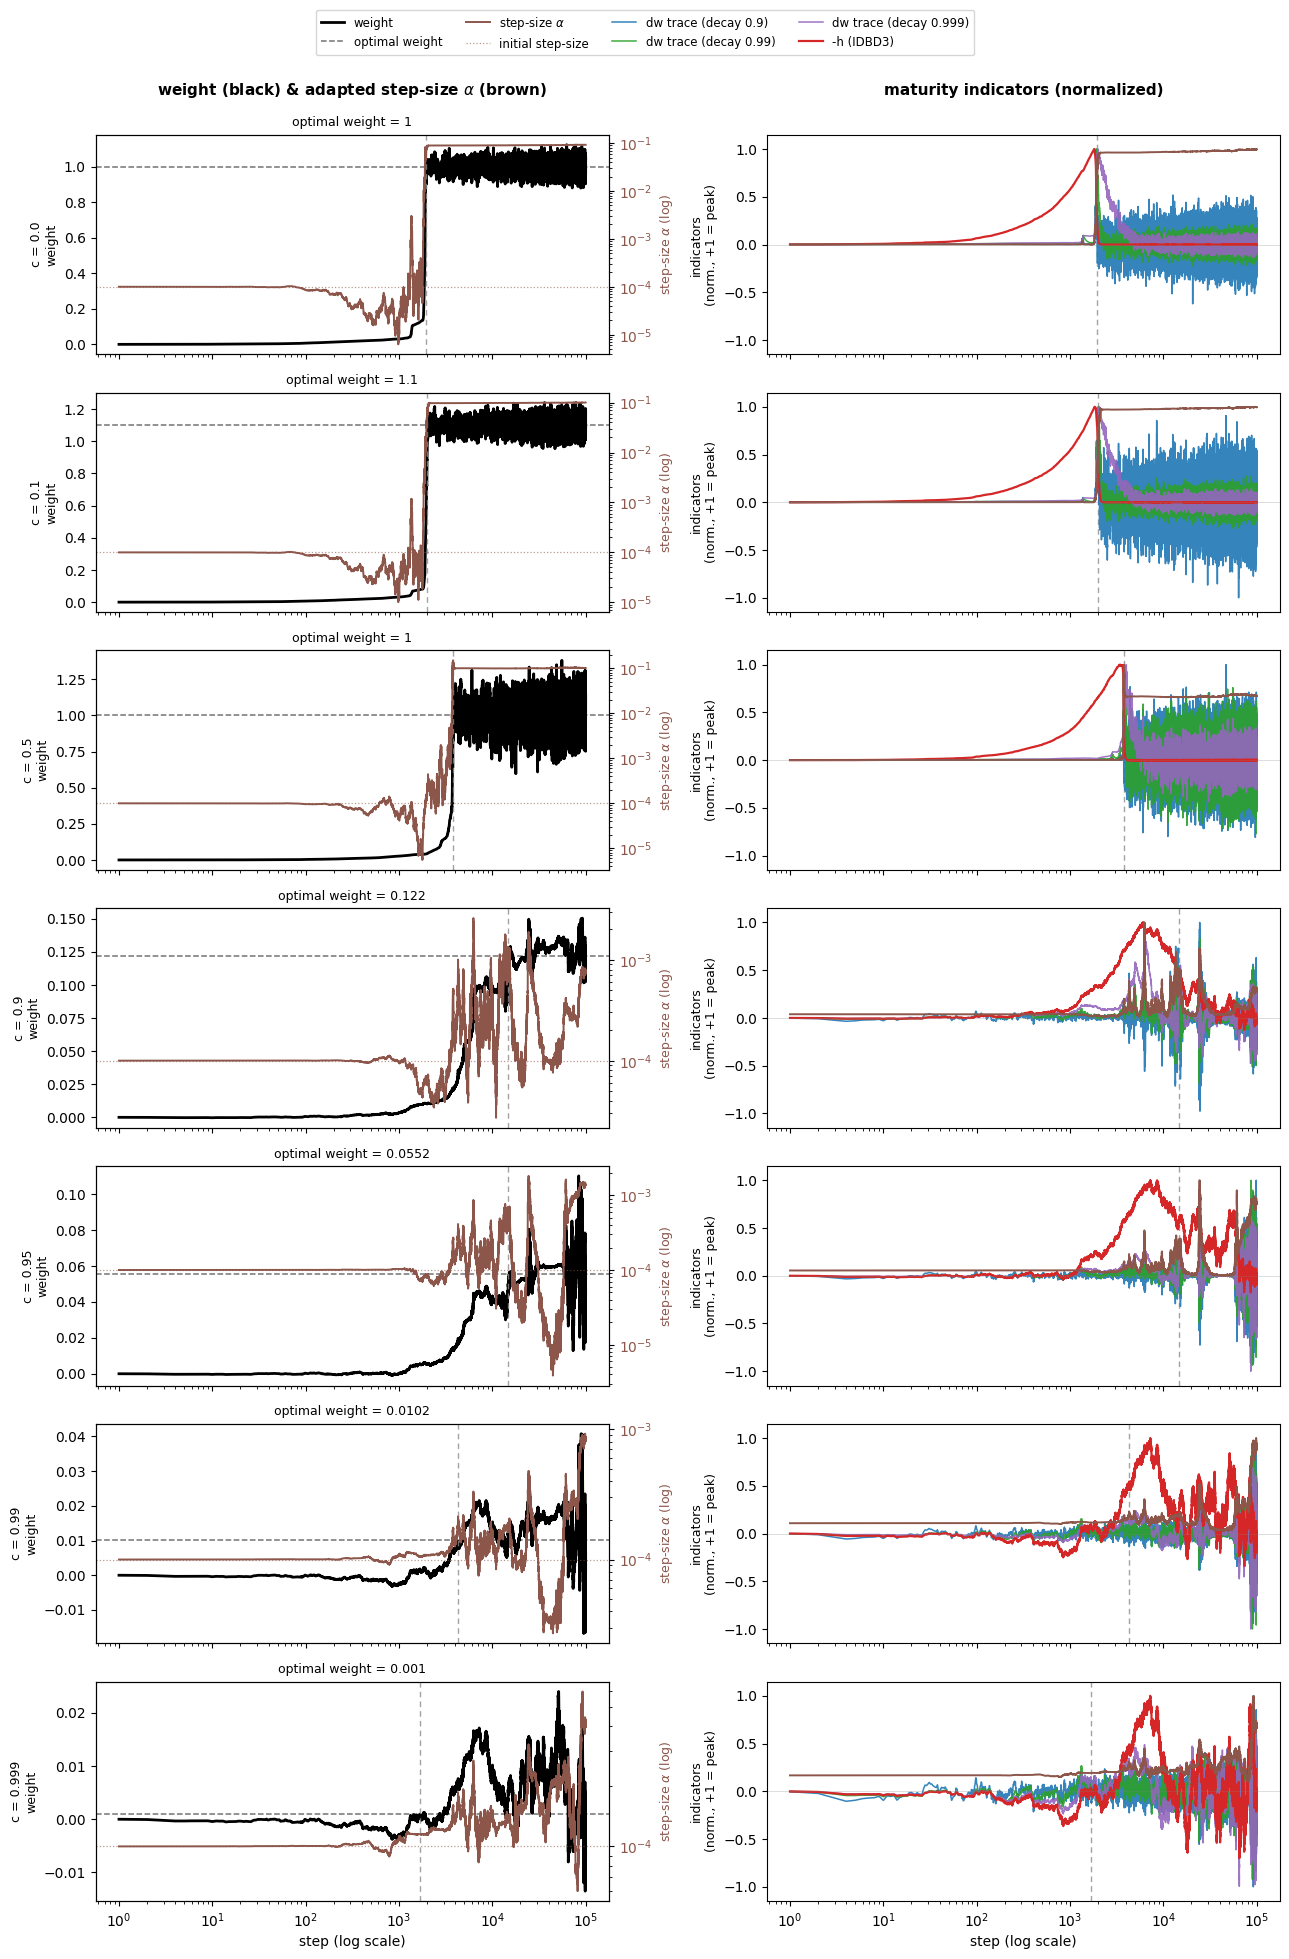

In [15]:
plot_steps = np.arange(1, EXP4_N_STEPS + 1)
ALPHA_COLOR = 'tab:brown'

fig, axes = plt.subplots(len(EXP4_FEATURE_NOISES), 2,
                         figsize=(13, 2.8 * len(EXP4_FEATURE_NOISES)), sharex=True)
axLa_first = None
for row, c in enumerate(EXP4_FEATURE_NOISES):
    axL, axR = axes[row]
    res = idbd3_results[c]
    w_opt = optimal_weight(TARGET_WEIGHT, c)
    alpha_tr = res['alpha'][:, -1]

    # --- left column: weight (true scale, black) + adapted step-size (log, right) ---
    axL.plot(plot_steps, res['w'][:, -1], color='black', lw=2.0, label='weight')
    axL.axhline(w_opt, color='black', ls='--', lw=1.1, alpha=0.55,
                label='optimal weight')
    axL.set_xscale('log'); axL.set_ylabel(f'c = {c}\nweight', fontsize=9)
    axL.set_title(f'optimal weight = {w_opt:.3g}', fontsize=9)

    axLa = axL.twinx()
    axLa.plot(plot_steps, alpha_tr, color=ALPHA_COLOR, lw=1.4, label='step-size '+r'$\alpha$')
    axLa.axhline(EXP4_INIT_LR, color=ALPHA_COLOR, ls=':', lw=0.9, alpha=0.6,
                 label='initial step-size')
    axLa.set_yscale('log'); axLa.set_ylabel(r'step-size $\alpha$ (log)', color=ALPHA_COLOR,
                                            fontsize=9)
    axLa.tick_params(axis='y', labelcolor=ALPHA_COLOR)
    if axLa_first is None:
        axLa_first = axLa

    # rough "matured" reference: weight first reaches 90% of its optimum
    if w_opt > 0:
        hit = np.where(res['w'][:, -1] >= 0.9 * w_opt)[0]
        if len(hit):
            for a in (axL, axR):
                a.axvline(hit[0] + 1, color='0.55', ls=(0, (4, 3)), lw=1.0, alpha=0.8)

    # --- right column: normalized maturity indicators (incl. the step-size) ---
    for k, d in enumerate(TRACE_DECAYS):
        axR.plot(plot_steps, _norm_peak(res['dw_trace'][:, k]),
                 color=DW_COLORS[k], lw=1.1, alpha=0.9, label=f'dw trace (decay {d})')
    axR.plot(plot_steps, _norm_peak(-res['h_idbd3']), color=H_IDBD3_COLOR, lw=1.6,
             label='-h (IDBD3)')
    axR.plot(plot_steps, _norm_peak(alpha_tr), color=ALPHA_COLOR, lw=1.4,
             label='step-size '+r'$\alpha$')
    axR.axhline(0.0, color='0.5', lw=0.6, alpha=0.3)
    axR.set_xscale('log'); axR.set_ylim(-1.15, 1.15)
    axR.set_ylabel('indicators\n(norm., +1 = peak)', fontsize=9)

axes[0][0].annotate('weight (black) & adapted step-size '+r'$\alpha$'+' (brown)',
                    xy=(0.5, 1.18), xycoords='axes fraction', ha='center',
                    fontsize=11, fontweight='bold')
axes[0][1].annotate('maturity indicators (normalized)', xy=(0.5, 1.18),
                    xycoords='axes fraction', ha='center', fontsize=11,
                    fontweight='bold')
axes[-1][0].set_xlabel('step (log scale)')
axes[-1][1].set_xlabel('step (log scale)')

hL, lL = axes[0][0].get_legend_handles_labels()
hLa, lLa = axLa_first.get_legend_handles_labels()
hR, lR = axes[0][1].get_legend_handles_labels()
# de-duplicate the shared step-size label across the left/right legends
seen = set()
H, L = [], []
for h_, l_ in zip(hL + hLa + hR, lL + lLa + lR):
    if l_ not in seen:
        seen.add(l_); H.append(h_); L.append(l_)
fig.legend(H, L, loc='upper center', ncol=4, fontsize=8.5, bbox_to_anchor=(0.5, 1.0))
fig.tight_layout(rect=(0, 0, 1, 0.965))
plt.show()


### Reading the plots — adaptive IDBD3

The same feature-noise sweep, but now the step-size is **meta-learned by IDBD3** (the
project's `optax_idbd3`, linear `prediction_grads` version) from a very small start
($\alpha_0 = 10^{-4}$, brown dotted line), one **row per noise level** $c$ (noisier going
down). The meta-update is driven by the **prediction gradient** $x$ and, because the
model is linear, the $h$-decay term is just $x^2$:
$$\beta \leftarrow \beta + \eta\, x\, h,\qquad \alpha = e^{\beta},\qquad
h \leftarrow h\,[1 - \alpha x^2]^+ + \text{loss\_grad}.$$

**Left column.** Black = the weight (dashed = the attenuated optimum $w^*(c)$); brown
(right axis, **log**) = the adapted step-size $\alpha$. The story the comment asked for:
$\alpha$ sits near its tiny start while $h$ builds up, then **ramps up sharply right as
the weight is learned**, and **settles at a plateau** whose level *falls with noise* —
$\sim10^{-1}$ for the clean feature, down to $\sim10^{-4}$ for the near-pure-noise rows.
IDBD3 recovers on its own the hand-tuned "smaller step-size for noisier features" of
experiment 3, and the weight lands on $w^*(c)$ at every level (the high-noise rows wobble
around their tiny optimum once $\alpha$ is up, but stay centred on it).

**Right column.** The candidate maturity indicators, each normalized to unit peak: the
$dw$ EMA traces, the IDBD3 $-h$ trace, and the step-size $\alpha$ itself. The grey
vertical dashed line is the rough "matured" step (weight first hits 90% of $w^*$). The
question carried through all four experiments — *which signal best says "this feature has
matured"?* — now has two adaptive contenders: $-h$ **rises to a clean peak right at the
maturity line** then falls (the sharpest single marker), and $\alpha$ itself steps from
flat to its plateau at the same moment. Both come for free once the step-size adapts, and
neither needs a hand-set step-size like the fixed-LMS indicators did.

**Note.** `meta_lr` is kept modest ($3\times10^{-4}$). Bare IDBD3 has no autostep
effective-step normalization, so an aggressive meta rate lets the unnormalised step-size
run away at low noise; a tiny initial step plus a modest meta rate ramps cleanly and stays
stable at every $c$. Capping that run-away is exactly what the project's autostep
normalization ($\text{eff} = \mathrm{clip}(\sum \alpha x^2,\,\min{=}1)$) adds — the
step-size-optimization experiment flagged as future work above.
